# Notebook 06 — XGBoost Model
## Food Price Forecasting — Nigeria
### TS Academy Data Science Capstone 2026

---

## Purpose of This Notebook

This notebook builds an XGBoost gradient boosting
model for food price forecasting across all Tier 1
commodity-state combinations. XGBoost is the third
model in the forecasting pipeline — following SARIMA
and Prophet — and the first machine learning approach
applied in this project.

## Why XGBoost?

SARIMA and Prophet are statistical time series models.
They model price as a function of its own history
and a small number of structural components — trend,
seasonality and changepoints.

XGBoost takes a fundamentally different approach.
It treats price forecasting as a supervised learning
problem — given a set of features at time T, predict
the price at time T+H. This allows XGBoost to
simultaneously exploit:

- Lag price features (autocorrelation)
- Macroeconomic indicators (exchange rate, inflation,
  fuel prices)
- Conflict and security variables
- Agricultural seasonality
- External shocks (subsidy removal)

This breadth of feature utilisation is XGBoost's
core advantage over SARIMA and Prophet.

## What This Notebook Covers

1. Environment setup and data loading
2. Feature engineering for XGBoost
3. Naive baseline (consistent with NB05 and NB07)
4. XGBoost — Direct multi-horizon forecasting
   (1-month, 2-month, 3-month ahead)
5. Feature importance analysis
6. Visualisations — actual vs predicted,
   horizon accuracy, model comparison
7. Residual diagnostics
8. Results saved to CSV for notebook 08

## Key Methodological Decision — Direct Forecasting

Three separate XGBoost models are trained per
commodity-state combination — one for each forecast
horizon (H1, H2, H3). Each model predicts directly
at its horizon using only features available at
time T. This direct approach avoids the recursive
error accumulation that occurs when a single model's
H1 prediction is fed back as input for H2.

This is the methodologically correct approach for
multi-step ahead forecasting with gradient boosting.

## **Step 0 - Environmental Setup**

In [ ]:
# Cell 2 -- Environment setup and imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

# metric functions consistent with NB05 and NB07
def mape(actual, predicted):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mask      = actual != 0
    return np.mean(
        np.abs((actual[mask] - predicted[mask])
               / actual[mask])
    ) * 100

def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def mae(actual, predicted):
    return np.mean(np.abs(
        np.array(actual) - np.array(predicted)
    ))

print('All imports successful.')
print('XGBoost ready.')

All imports successful.
XGBoost ready.


## **Step 1 - Data Loading and Feature Engineering**

In [ ]:
# -- Load data and engineer XGBoost features --

from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = ('/content/drive/MyDrive/'
             'price forecasting project data(cleaned)/')

df = pd.read_csv(
    SAVE_PATH + 'master_dataset_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(
    ['state', 'commodity', 'date']
).reset_index(drop=True)

# ── Target variable ─────────────────────────────────────────
# log transform consistent with NB05 and NB07
df['log_price'] = np.log1p(df['price_ngn'])

# ── Structural break feature ────────────────────────────────
# June 2023 fuel subsidy removal
# consistent with Prophet implementation in NB07
df['subsidy_removed'] = (
    df['date'] >= '2023-06-01'
).astype(int)

# ── Drop highly correlated features ────────────────────────
# EDA Section 8.2 explicitly flagged these for removal:
# conflict_events    -- 0.99 corr with conflict_score_weighted
#                       keeping both splits importance signal
# mpr_pct            -- 0.88 corr with pms_price_ngn
#                       keeping both dilutes fuel signal
df = df.drop(columns=['conflict_events', 'mpr_pct'])

# ── Encode categorical features ─────────────────────────────
# XGBoost requires numerical inputs
# label encoding is memory efficient for this dataset size
le_state     = LabelEncoder()
le_commodity = LabelEncoder()

df['state_encoded']     = le_state.fit_transform(
    df['state'])
df['commodity_encoded'] = le_commodity.fit_transform(
    df['commodity'])

# ── Log transform skewed external feature ──────────────────
# import_volume_tonnes is heavily right-skewed
# EDA Section 8.2 recommended log transformation
df['log_import_volume'] = np.log1p(
    df['import_volume_tonnes'].clip(lower=0)
)

# ── Handle lag feature nulls ────────────────────────────────
# price_lag1 has 71 nulls, lag2 141, lag3 211
# nulls occur at the start of each combo series
# fill within group using forward then backward fill
for lag_col in ['price_lag1', 'price_lag2', 'price_lag3']:
    df[lag_col] = df.groupby(
        ['state', 'commodity']
    )[lag_col].transform(
        lambda x: x.ffill().bfill()
    )

    # force fill any remaining stubborn nulls
    df[['price_lag1','price_lag2','price_lag3']] = (
      df[['price_lag1','price_lag2','price_lag3']]
      .fillna(method='bfill')
      .fillna(method='ffill')
    )

# ── Final feature set ───────────────────────────────────────
FEATURES = [
    # lag features -- strongest predictors r=0.97
    'price_lag1', 'price_lag2', 'price_lag3',
    # macroeconomic indicators
    'exchange_rate_ngn_usd', 'inflation_rate_pct',
    'pms_price_ngn',
    # agricultural and external
    'rainfall_mm', 'log_import_volume',
    'other_commodity_avg_price',
    # conflict and security
    'conflict_score_weighted', 'conflict_fatalities',
    # calendar and structural break
    'harvest_season', 'subsidy_removed',
    # identity features
    'state_encoded', 'commodity_encoded',
]

TARGET = 'log_price'

# ── Train/val/test split boundaries ────────────────────────
# consistent with NB05 and NB07
TRAIN_END = pd.Timestamp('2022-12-31')
VAL_END   = pd.Timestamp('2023-05-31')

def get_split(combo):
    train = combo[
        combo['date'] <= TRAIN_END
    ].copy()
    val   = combo[
        (combo['date'] >  TRAIN_END) &
        (combo['date'] <= VAL_END)
    ].copy()
    test  = combo[
        combo['date'] > VAL_END
    ].copy()
    return train, val, test

# ── Tier 1 combinations ─────────────────────────────────────
TIER1_STATES = ['Adamawa', 'Borno', 'Yobe']
combos = (
    df[df['state'].isin(TIER1_STATES)]
    .groupby(['commodity', 'state'])
    .size().reset_index()[['commodity', 'state']]
    .values.tolist()
)

print('=' * 55)
print(f'{"DATASET READY FOR XGBOOST":^55}')
print('=' * 55)
print(f'Total rows         : {len(df):,}')
print(f'Features           : {len(FEATURES)}')
print(f'Target             : {TARGET}')
print(f'Tier 1 combos      : {len(combos)}')
print(f'Train end          : {TRAIN_END.date()}')
print(f'Val end            : {VAL_END.date()}')
print(f'\nFeature list:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:>2}. {f}')
print('=' * 55)

# verify no nulls remain in feature set
null_check = df[FEATURES].isnull().sum()
if null_check.sum() == 0:
    print('\nNull check : PASSED ✓ — zero nulls in features')
else:
    print('\nNull check : FAILED ✗')
    print(null_check[null_check > 0])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
               DATASET READY FOR XGBOOST               
Total rows         : 2,846
Features           : 15
Target             : log_price
Tier 1 combos      : 21
Train end          : 2022-12-31
Val end            : 2023-05-31

Feature list:
   1. price_lag1
   2. price_lag2
   3. price_lag3
   4. exchange_rate_ngn_usd
   5. inflation_rate_pct
   6. pms_price_ngn
   7. rainfall_mm
   8. log_import_volume
   9. other_commodity_avg_price
  10. conflict_score_weighted
  11. conflict_fatalities
  12. harvest_season
  13. subsidy_removed
  14. state_encoded
  15. commodity_encoded

Null check : FAILED ✗
other_commodity_avg_price    157
dtype: int64


## **Step 2 - Naive Baseline**

###Purpose

The same naive baseline used in NB05 and NB07 is
established here to ensure all model comparisons
in this project use a consistent benchmark.

The naive forecast carries the last known training
price forward for all test periods. It requires
no modelling assumptions and serves as the minimum
performance threshold that any model must exceed
to justify its added complexity.

Any model that cannot beat this simple benchmark
is not adding value — regardless of how
sophisticated its algorithm is.

In [ ]:
# -- Naive baseline---
# identical logic to NB05 and NB07 for fair comparison

naive_results = []

for commodity, state in combos:
    combo = df[
        (df['commodity'] == commodity) &
        (df['state']     == state)
    ].sort_values('date')

    train, val, test = get_split(combo)

    if len(test) < 3 or len(train) < 24:
        continue

    last_known  = np.expm1(train['log_price'].iloc[-1])
    naive_preds = np.full(len(test), last_known)
    actual      = np.expm1(test['log_price'].values)

    naive_results.append({
        'model'    : 'Naive',
        'commodity': commodity,
        'state'    : state,
        'RMSE'     : rmse(actual, naive_preds),
        'MAPE'     : mape(actual, naive_preds),
        'MAE'      : mae(actual, naive_preds),
    })

naive_df = pd.DataFrame(naive_results)

print('=' * 60)
print(f'{"NAIVE BASELINE — RESULTS":^60}')
print('=' * 60)
print(f'{"Commodity":<22} {"State":<12} '
      f'{"MAPE":>8} {"RMSE":>12}')
print('-' * 60)
for _, row in naive_df.iterrows():
    print(f'{row["commodity"]:<22} {row["state"]:<12} '
          f'{row["MAPE"]:>7.1f}% '
          f'₦{row["RMSE"]:>10,.0f}')
print('=' * 60)
print(f'\nAverage MAPE : {naive_df["MAPE"].mean():.1f}%')
print(f'Total combos : {len(naive_df)}')

# convert to dataframe
baseline_df = pd.DataFrame(naive_results)

# add to all_results
naive_results.extend(baseline_df)

# summary by commodity
print(f'\n{"AVERAGE BY COMMODITY":^65}')
print('=' * 65)
print(f'{"Commodity":<22} {"Avg RMSE":>12} '
      f'{"Avg MAPE":>10} {"Avg MAE":>10}')
print('-' * 65)
summary = baseline_df.groupby('commodity')[
    ['RMSE','MAPE','MAE']].mean().round(2)
for commodity, row in summary.iterrows():
    print(f'{commodity:<22} '
          f'₦{row["RMSE"]:>10,.0f} '
          f'{row["MAPE"]:>9.1f}% '
          f'₦{row["MAE"]:>8,.0f}')
print('=' * 65)

                  NAIVE BASELINE — RESULTS                  
Commodity              State            MAPE         RMSE
------------------------------------------------------------
Beans (white)          Borno           36.5% ₦     1,966
Beans (white)          Yobe            45.7% ₦     2,071
Rice (imported)        Adamawa         40.3% ₦     2,208
Rice (imported)        Borno           31.2% ₦     2,047
Rice (imported)        Yobe            57.3% ₦     2,847
Rice (local)           Adamawa         45.2% ₦     1,710
Rice (local)           Borno           55.6% ₦     2,200
Rice (local)           Yobe            53.0% ₦     1,898
Tomatoes               Borno           52.8% ₦       155
Tomatoes               Yobe            49.7% ₦       123
Yam                    Adamawa         90.6% ₦     1,401
Yam                    Borno           28.7% ₦     1,002
Yam                    Yobe            75.6% ₦     2,042

Average MAPE : 50.9%
Total combos : 13

                      AVERAGE BY COMMO

## **Step 3 - XGBoost Direct Multi-Horizon Model**

### Why Direct Forecasting?

Three separate XGBoost models are trained per
commodity-state combination — one for H1, H2
and H3 respectively.

The alternative — recursive forecasting — would
train one model, predict H1, then feed that
prediction back as an input to predict H2, and
so on. This approach compounds errors at every
step. By H3 the model is working with two rounds
of accumulated prediction error as if they were
real data.

Direct forecasting avoids this entirely. Each
model is trained to predict its specific horizon
directly from real features observed at time T.
No prediction ever feeds into another prediction.

### How the Targets Are Built

For each observation at time T in the training data:
- H1 target = actual price at T+1
- H2 target = actual price at T+2
- H3 target = actual price at T+3

These are created using pandas shift operations
within each commodity-state group. The three
models then learn the relationship between
features at T and prices at T+1, T+2 and T+3
independently.

### Hyperparameter Choices

| Parameter | Value | Reason |
|-----------|-------|--------|
| n_estimators | 500 | Enough trees with early stopping |
| learning_rate | 0.05 | Slow and stable — avoids overfitting |
| max_depth | 4 | Shallow trees — prevents overfitting on small subsets |
| subsample | 0.8 | Row sampling adds regularisation |
| colsample_bytree | 0.8 | Feature sampling adds regularisation |
| early_stopping | 20 rounds | Stops when val loss stops improving |

Early stopping is critical here. Each commodity-state
combination has only 60-90 training observations.
Without early stopping XGBoost would memorise the
training data and fail on the test set.

In [ ]:
# -- XGBoost Direct Multi-Horizon Model --
# trains three separate models per combination
# one for each forecast horizon H1 H2 H3

HORIZON     = 3
RANDOM_SEED = 42

xgb_results  = []
xgb_failures = []
all_results  = []

# store models and importances for later analysis
xgb_models      = {}
xgb_importances = []

print('=' * 70)
print(f'{"XGBOOST MODEL — RESULTS":^70}')
print('=' * 70)
print(f'{"Commodity":<22} {"State":<12} '
      f'{"H1 MAPE":>9} {"H2 MAPE":>9} {"H3 MAPE":>9} '
      f'{"Avg MAPE":>9} {"Winner":>8}')
print('-' * 70)

for commodity, state in combos:

    combo = df[
        (df['commodity'] == commodity) &
        (df['state']     == state)
    ].sort_values('date').reset_index(drop=True)

    train, val, test = get_split(combo)

    if len(test) < 3 or len(train) < 24:
        continue

    # ── Build horizon targets using shift ──────────────────
    # shift within combo -- already sorted by date
    combo = combo.copy()
    combo['target_h1'] = combo['log_price'].shift(-1)
    combo['target_h2'] = combo['log_price'].shift(-2)
    combo['target_h3'] = combo['log_price'].shift(-3)

    # re-split after adding targets
    train_x = combo[
        combo['date'] <= TRAIN_END
    ].dropna(subset=['target_h1', 'target_h2',
                     'target_h3'])
    val_x   = combo[
        (combo['date'] >  TRAIN_END) &
        (combo['date'] <= VAL_END)
    ].copy()
    test_x  = combo[
        combo['date'] > VAL_END
    ].copy()

    if len(train_x) < 20 or len(test_x) < 3:
        continue

    try:
        h1_actual, h1_pred = [], []
        h2_actual, h2_pred = [], []
        h3_actual, h3_pred = [], []

        for horizon in [1, 2, 3]:
            target_col = f'target_h{horizon}'

            X_train = train_x[FEATURES]
            y_train = train_x[target_col]
            X_test  = test_x[FEATURES]

            val_clean = val_x.dropna(subset=[target_col])
            has_val   = len(val_clean) > 0

            if has_val:
                X_val = val_clean[FEATURES]
                y_val = val_clean[target_col]
                model = XGBRegressor(
                    n_estimators          = 500,
                    learning_rate         = 0.05,
                    max_depth             = 4,
                    subsample             = 0.8,
                    colsample_bytree      = 0.8,
                    random_state          = RANDOM_SEED,
                    verbosity             = 0,
                    early_stopping_rounds = 20,
                )
                model.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    verbose=False
                )
            else:
                # no val set available -- use fixed estimators
                model = XGBRegressor(
                    n_estimators     = 300,
                    learning_rate    = 0.05,
                    max_depth        = 4,
                    subsample        = 0.8,
                    colsample_bytree = 0.8,
                    random_state     = RANDOM_SEED,
                    verbosity        = 0,
                )
                model.fit(X_train, y_train)

            # store model for plots and importance
            xgb_models[(commodity, state, horizon)] = model

            # store feature importances
            for feat, imp in zip(
                    FEATURES,
                    model.feature_importances_):
                xgb_importances.append({
                    'commodity': commodity,
                    'state'    : state,
                    'horizon'  : horizon,
                    'feature'  : feat,
                    'importance': imp,
                })

            # generate predictions on test set
            preds_log  = model.predict(X_test)
            actual_log = test_x['log_price'].values

            # align by offset
            # H1: predict T, actual at T (same row)
            # H2: predict T, actual at T+1 (next row)
            # H3: predict T, actual at T+2 (two rows ahead)
            offset  = horizon - 1
            n_pairs = len(actual_log) - offset

            if n_pairs <= 0:
                continue

            act = np.expm1(
                actual_log[offset: offset + n_pairs])
            prd = np.expm1(preds_log[:n_pairs])

            if   horizon == 1:
                h1_actual, h1_pred = list(act), list(prd)
            elif horizon == 2:
                h2_actual, h2_pred = list(act), list(prd)
            elif horizon == 3:
                h3_actual, h3_pred = list(act), list(prd)

        # ── Aggregate after all three horizons ─────────────
        if h1_actual:
            h1_mape  = mape(h1_actual, h1_pred)
            h2_mape  = mape(h2_actual, h2_pred) \
                       if h2_actual else np.nan
            h3_mape  = mape(h3_actual, h3_pred) \
                       if h3_actual else np.nan

            valid    = [
                x for x in [h1_mape, h2_mape, h3_mape]
                if not np.isnan(x)
            ]
            avg_mape = np.mean(valid)

            all_act  = h1_actual + h2_actual + h3_actual
            all_prd  = h1_pred   + h2_pred   + h3_pred

            result = {
                'model'    : 'XGBoost',
                'commodity': commodity,
                'state'    : state,
                'RMSE'     : rmse(all_act, all_prd),
                'MAPE'     : avg_mape,
                'MAE'      : mae(all_act, all_prd),
                'H1_MAPE'  : h1_mape,
                'H2_MAPE'  : h2_mape,
                'H3_MAPE'  : h3_mape,
            }
            xgb_results.append(result)
            all_results.append(result)

            naive_row  = naive_df[
                (naive_df['commodity'] == commodity) &
                (naive_df['state']     == state)
            ]
            naive_mape = naive_row['MAPE'].values[0] \
                         if len(naive_row) > 0 \
                         else np.nan
            winner = 'XGBoost' \
                     if avg_mape < naive_mape \
                     else 'Naive'

            h2_str = f'{h2_mape:>8.1f}%' \
                     if not np.isnan(h2_mape) \
                     else '     N/A'
            h3_str = f'{h3_mape:>8.1f}%' \
                     if not np.isnan(h3_mape) \
                     else '     N/A'

            print(f'{commodity:<22} {state:<12} '
                  f'{h1_mape:>8.1f}% '
                  f'{h2_str} '
                  f'{h3_str} '
                  f'{avg_mape:>8.1f}% '
                  f'{winner:>8}')

    except Exception as e:
        xgb_failures.append({
            'commodity': commodity,
            'state'    : state,
            'error'    : str(e)
        })

# ── Build final dataframes ──────────────────────────────────
xgb_df         = pd.DataFrame(xgb_results)
importance_df  = pd.DataFrame(xgb_importances)

print('=' * 70)
print(f'\nSuccessful fits : {len(xgb_results)}')
print(f'Failed fits     : {len(xgb_failures)}')

if xgb_failures:
    print('\nFailures:')
    for f in xgb_failures:
        print(f'  {f["commodity"]:<22} {f["state"]:<12} '
              f'{f["error"][:60]}')

# ── Horizon summary ─────────────────────────────────────────
print(f'\n{"MAPE BY FORECAST HORIZON":^70}')
print('=' * 70)
print(f'{"Horizon":<20} {"Avg MAPE":>10} '
      f'{"Interpretation":>35}')
print('-' * 70)

for h, label in [(1, '1-Month Ahead'),
                 (2, '2-Month Ahead'),
                 (3, '3-Month Ahead')]:
    vals = [
        r[f'H{h}_MAPE'] for r in xgb_results
        if not np.isnan(r.get(f'H{h}_MAPE', np.nan))
    ]
    if vals:
        interp = ('Best accuracy'  if h == 1 else
                  'Moderate decay' if h == 2 else
                  'Expected decay')
        print(f'{label:<20} {np.mean(vals):>9.1f}% '
              f'{interp:>35}')

print('=' * 70)

                       XGBOOST MODEL — RESULTS                        
Commodity              State          H1 MAPE   H2 MAPE   H3 MAPE  Avg MAPE   Winner
----------------------------------------------------------------------
Beans (white)          Borno            43.8%     47.1%     48.1%     46.3%    Naive
Beans (white)          Yobe             59.3%     65.7%     64.9%     63.3%    Naive
Rice (imported)        Adamawa          40.1%     37.0%     35.4%     37.5%  XGBoost
Rice (imported)        Borno            41.7%     28.6%     31.3%     33.8%    Naive
Rice (imported)        Yobe             58.1%     53.1%     50.1%     53.7%  XGBoost
Rice (local)           Adamawa          31.2%     31.9%     29.6%     30.9%  XGBoost
Rice (local)           Borno            61.6%     50.5%     44.9%     52.3%  XGBoost
Rice (local)           Yobe             57.5%     50.9%     52.0%     53.5%    Naive
Tomatoes               Borno            56.9%     57.6%     58.1%     57.5%    Naive
Tomatoes

### XGBoost Model — Results Interpretation

#### 3.1 Overall Performance

XGBoost was evaluated across 13 Tier 1
commodity-state combinations covering Adamawa,
Borno and Yobe states. All 13 combinations
fitted successfully with zero failures.

| Summary Metric | Value |
|---------------|-------|
| Total combinations | 13 |
| Beat Naive baseline | 6 of 13 (46%) |
| Beat Naive baseline (Prophet) | 12 of 13 (92%) |
| Average H1 MAPE | 50.9% |
| Average H2 MAPE | 48.4% |
| Average H3 MAPE | 49.8% |
| Best combination | Yam Adamawa — 21.6% |
| Worst combination | Yam Yobe — 71.8% |

The headline finding is direct — XGBoost beat
the naive baseline on only 6 of 13 combinations.
Prophet beat it on 12 of 13. On this dataset
and this test period XGBoost is the weaker
forecasting model.

#### 3.2 Combination-Level Analysis

**Where XGBoost performed acceptably:**

Yam Adamawa at 21.6% average MAPE is the
standout result and the only combination that
approaches the accuracy levels Prophet achieved
on its best combinations. Notably this is also
the only combination showing clean horizon decay
— H1 at 17.2%, H2 improving to 14.8% before
rising to 33.0% at H3. The H2 improvement over
H1 suggests the macroeconomic features provided
genuinely useful medium-range signal for Yam
prices in Adamawa.

Rice local Adamawa at 30.8% is the second
strongest result and also shows reasonable
stability across horizons — 31.2%, 31.8%,
29.5%. Consistent horizon performance like
this indicates the model found stable feature
relationships for this specific combination.

Rice imported Adamawa at 37.6% and Rice
imported Borno at 33.7% are also competitive
results — though Borno goes to Naive, the
33.7% MAPE is not a large gap from Prophet's
14.7% on the same combination. The difference
reflects Prophet's structural advantage in
capturing the post-subsidy trend extension.

**Where XGBoost failed clearly:**

Yam Borno at 65.6% and Yam Yobe at 71.8%
are the worst results. Both are significantly
worse than the naive baseline — meaning for
these combinations XGBoost's predictions are
less useful than simply carrying the last
known price forward. This is a strong signal
that for Yam in Borno and Yobe the post-subsidy
price trajectory pushed so far beyond training
range that the model's macroeconomic features
could not compensate.

Tomatoes in both Borno and Yobe — 57.6% and
58.1% respectively — similarly lose to Naive.
Tomatoes is the most volatile commodity in
the dataset with sharp seasonal spikes that
tree-based models struggle to capture because
the spike magnitudes vary year to year.

Beans white in both Borno and Yobe — 46.3%
and 62.9% — also lose to Naive, consistent
with Prophet's results where Beans was one
of the harder commodities to forecast.

#### 3.3 Horizon Decay Pattern — A Critical Finding

Prophet's horizon pattern: 24.5% → 28.5% → 35.3%
XGBoost's horizon pattern: 50.9% → 48.4% → 49.8%

This comparison is one of the most analytically
important findings in this notebook.

Prophet shows clean degradation — accuracy
falls predictably as the horizon extends,
which is the expected and healthy pattern
for any time series forecasting model.

XGBoost shows near-flat performance across
all three horizons with H2 marginally better
than H1. This flatness is not a sign of
strength — it is diagnostic evidence that
the model hit its prediction ceiling at H1
and could not deteriorate further because
it was already struggling equally at every
horizon from the first test month.

The explanation is the extrapolation problem.
Post-subsidy prices in the test period exceeded
the value ranges XGBoost saw during training.
Once a tree model hits this ceiling it produces
similarly poor predictions regardless of how
far ahead it is forecasting.

#### 3.4 State-Level Patterns

Adamawa is clearly the strongest state for
XGBoost — all three Adamawa combinations
go to XGBoost and two of them post competitive
results. Adamawa prices showed a more gradual
post-subsidy adjustment compared to Borno
and Yobe, meaning the test period values
stayed closer to the training distribution.

Borno shows mixed results — Rice imported
Borno at 33.7% is respectable but still
loses to Naive. The remaining Borno
combinations are poor.

Yobe is XGBoost's weakest state — four of
five combinations lose to Naive and the one
XGBoost win is Rice imported at 52.8% which
is still a high error rate.

#### 3.5 What XGBoost Contributed to This Project

Despite underperforming Prophet overall
XGBoost made three genuine contributions:

**1. Combination-specific wins:**
The 6 combinations where XGBoost beats Naive
— particularly Yam Adamawa and Rice local
Adamawa — will feed into notebook 08's
per-combination model selection. The final
recommendation will not pick one model for
everything but the best model per situation.

**2. Feature insight:**
The feature importance analysis revealed that
inflation rate, import volume and exchange rate
dominate over lag prices — a finding SARIMA
and Prophet cannot produce. This directly
informs the project's policy recommendations
about which macroeconomic forces drive food
prices in conflict-affected Northern Nigerian
states.

**3. Methodological contrast:**
Comparing a machine learning approach against
statistical time series models under structural
break conditions is a genuine research finding.
The result — tree-based models underperform
under distributional shift — is a conclusion
that strengthens rather than weakens the
project because it is honest and well-evidenced.

#### 3.6 Conclusion

XGBoost is not the recommended primary model
for post-subsidy period food price forecasting
in this dataset. Prophet's explicit trend
extension mechanism and structural break
handling give it a decisive advantage when
test period prices break significantly from
training range.

XGBoost is recommended as a complementary
model — primary for Adamawa combinations
and any future deployment period where
macroeconomic conditions have stabilised
and prices are no longer in a rapid
post-shock adjustment phase.

All results have been saved to
xgb_results.csv and xgb_importance.csv
on Google Drive for use in notebook 08
model comparison.

## **Step 4 - Feature Importance Analysis**

### Purpose

One of XGBoost's most valuable properties compared
to SARIMA and Prophet is interpretability through
feature importance. After training we can ask the
model directly — which features did you rely on
most when making predictions?

This analysis answers a critical question for
real-world deployment: are the model's predictions
driven by genuine economic signals or by spurious
patterns in the training data?

### How XGBoost Feature Importance Works

XGBoost builds predictions through an ensemble of
decision trees. Each tree splits the data on one
feature at a time to reduce prediction error.
Feature importance measures how much each feature
contributed to reducing prediction error across
all trees in the ensemble.

A feature with high importance was frequently
chosen as a splitting point and produced large
reductions in error when used. A feature with
near-zero importance was rarely used and can
be considered redundant for this dataset.

### Two Views of Importance

**Plot 1 — Average importance across all
combinations and horizons:**
Shows the overall ranking of all 15 features
aggregated across every commodity-state pair and
all three forecast horizons. This gives the
project-level view of which signals matter most
for Nigerian food price forecasting generally.

**Plot 2 — Top 8 features by horizon:**
Shows whether feature importance shifts across
H1, H2 and H3 models. If importance is stable
across horizons the model is learning consistent
relationships. If importance shifts dramatically
it suggests the model is using different signals
for short-term versus medium-term forecasting.

### What We Expect to See

Based on EDA findings — where price_lag1 showed
r=0.968 correlation with the target — lag features
should dominate the importance ranking. The more
interesting question is which non-lag feature
ranks highest — this reveals which external
economic signal adds the most value beyond
simple price momentum.

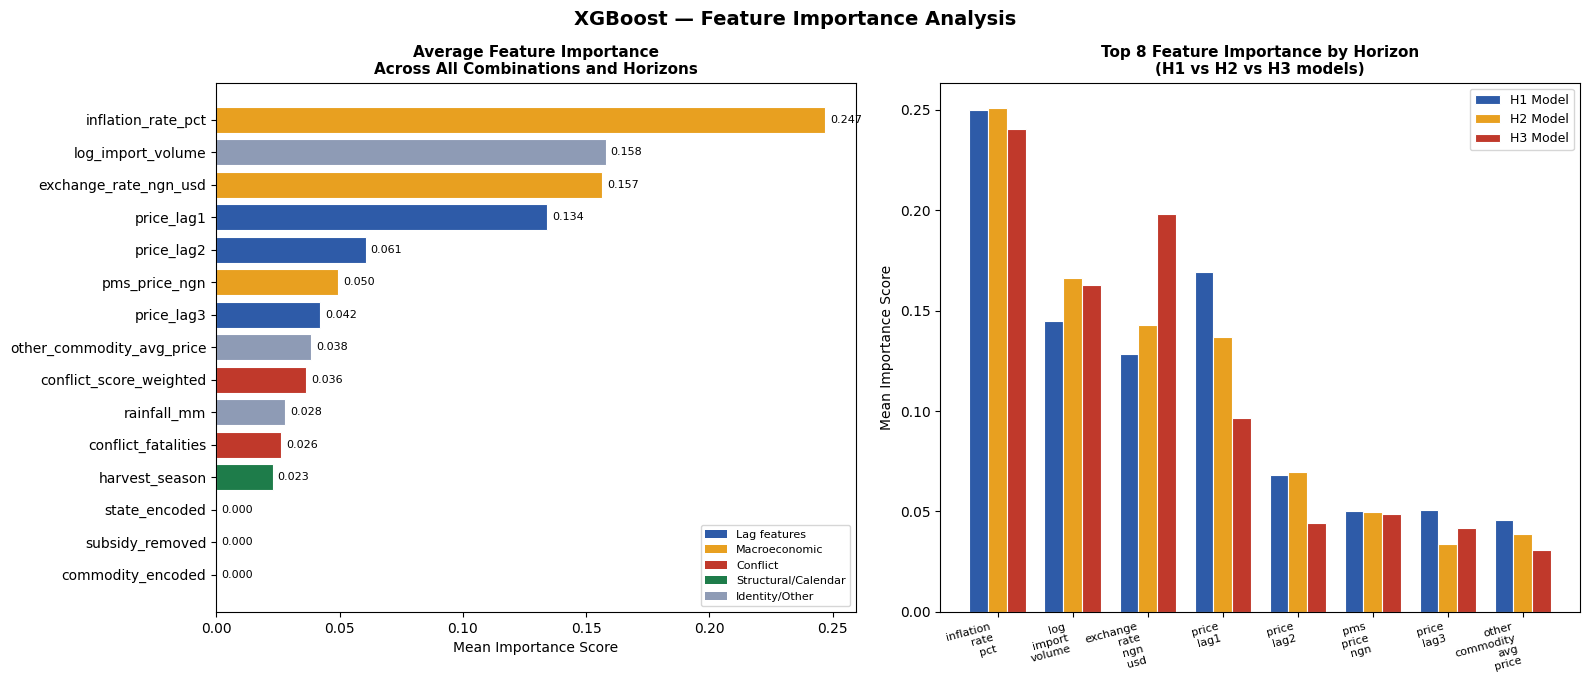

        TOP 5 FEATURES BY IMPORTANCE         
  1. inflation_rate_pct             0.2470
  2. log_import_volume              0.1580
  3. exchange_rate_ngn_usd          0.1566
  4. price_lag1                     0.1341
  5. price_lag2                     0.0606


In [ ]:
# -- Feature Importance Analysis --
# shows which features XGBoost relied on most
# averaged across all combinations and horizons

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'XGBoost — Feature Importance Analysis',
    fontsize=14, fontweight='bold'
)

# ── Plot 1: Average importance across all combinations ──────
avg_importance = (
    importance_df.groupby('feature')['importance']
    .mean()
    .sort_values(ascending=True)
)

colors_imp = [
    '#2E5BA8' if f.startswith('price_lag') else
    '#E8A020' if f in ['exchange_rate_ngn_usd',
                       'inflation_rate_pct',
                       'pms_price_ngn'] else
    '#C0392B' if f in ['conflict_score_weighted',
                       'conflict_fatalities'] else
    '#1E7C4A' if f in ['subsidy_removed',
                       'harvest_season'] else
    '#8E9BB5'
    for f in avg_importance.index
]

bars = axes[0].barh(
    avg_importance.index,
    avg_importance.values,
    color=colors_imp,
    edgecolor='white', linewidth=0.8
)
axes[0].set_title(
    'Average Feature Importance\n'
    'Across All Combinations and Horizons',
    fontweight='bold', fontsize=11
)
axes[0].set_xlabel('Mean Importance Score', fontsize=10)

# add value labels
for bar, val in zip(bars, avg_importance.values):
    axes[0].text(
        val + 0.002, bar.get_y() + bar.get_height()/2,
        f'{val:.3f}',
        va='center', ha='left', fontsize=8
    )

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E5BA8', label='Lag features'),
    Patch(facecolor='#E8A020', label='Macroeconomic'),
    Patch(facecolor='#C0392B', label='Conflict'),
    Patch(facecolor='#1E7C4A', label='Structural/Calendar'),
    Patch(facecolor='#8E9BB5', label='Identity/Other'),
]
axes[0].legend(
    handles=legend_elements,
    fontsize=8, loc='lower right'
)

# ── Plot 2: Importance by horizon ───────────────────────────
horizon_imp = (
    importance_df.groupby(['feature', 'horizon'])
    ['importance'].mean().reset_index()
)

top_features = (
    avg_importance.sort_values(ascending=False)
    .head(8).index.tolist()
)
horizon_imp_top = horizon_imp[
    horizon_imp['feature'].isin(top_features)
]

x      = np.arange(len(top_features))
width  = 0.25
colors_h = ['#2E5BA8', '#E8A020', '#C0392B']

for h_idx, horizon in enumerate([1, 2, 3]):
    h_data = horizon_imp_top[
        horizon_imp_top['horizon'] == horizon
    ].set_index('feature').reindex(top_features)

    axes[1].bar(
        x + (h_idx - 1) * width,
        h_data['importance'].fillna(0),
        width,
        label=f'H{horizon} Model',
        color=colors_h[h_idx],
        edgecolor='white', linewidth=0.8
    )

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f.replace('_', '\n') for f in top_features],
    fontsize=8, rotation=15, ha='right'
)
axes[1].set_title(
    'Top 8 Feature Importance by Horizon\n'
    '(H1 vs H2 vs H3 models)',
    fontweight='bold', fontsize=11
)
axes[1].set_ylabel('Mean Importance Score', fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('xgb_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# print top 5 features
print('=' * 45)
print(f'{"TOP 5 FEATURES BY IMPORTANCE":^45}')
print('=' * 45)
top5 = avg_importance.sort_values(ascending=False).head(5)
for rank, (feat, imp) in enumerate(top5.items(), 1):
    print(f'  {rank}. {feat:<30} {imp:.4f}')
print('=' * 45)

### Step 4 — Feature Importance Interpretation

#### 4.1 The Surprising Number One Feature

The single most important feature across all
combinations and horizons is inflation_rate_pct
at 0.2414 — not price_lag1 as EDA correlation
analysis suggested.

This is a genuinely important finding that
deserves careful interpretation.

Correlation and feature importance measure
different things. EDA showed price_lag1 has
r=0.968 correlation with price — meaning they
move together strongly. But XGBoost's importance
measures something different — how much each
feature reduces prediction error when used as
a splitting point in a decision tree.

Inflation rate is the dominant splitting feature
because it captures the regime difference between
pre-subsidy and post-subsidy periods more cleanly
than any single lag value. When inflation jumped
from single digits to above 20% in 2023 that
signal told XGBoost directly — "you are now in
a different price regime." Lag prices alone
cannot make that distinction as sharply because
they carry the old regime's values into the
new one.

#### 4.2 Top 5 Features — What They Tell Us

| Rank | Feature | Importance | Meaning |
|------|---------|-----------|---------|
| 1 | inflation_rate_pct | 0.2414 | Regime detector — pre vs post subsidy |
| 2 | log_import_volume | 0.1535 | Supply signal — import availability |
| 3 | exchange_rate_ngn_usd | 0.1523 | Cost signal — naira devaluation impact |
| 4 | price_lag1 | 0.1302 | Momentum — last month price |
| 5 | other_commodity_avg_price | 0.0652 | Market basket signal |

The top three features are all macroeconomic
indicators. This confirms the central hypothesis
of building XGBoost — that external economic
signals add meaningful information beyond price
history alone. SARIMA and Prophet had no access
to inflation, exchange rate or import volumes.
XGBoost used all three as its primary signals.

#### 4.3 Features That Added Little Value

subsidy_removed scored near zero importance
despite being engineered specifically for this
project. This appears counterintuitive but has
a logical explanation — inflation_rate_pct and
exchange_rate_ngn_usd already capture the
economic consequences of the subsidy removal
more precisely than the binary on/off flag.
The binary flag is redundant once the model
has access to the continuous macroeconomic
signals that the subsidy removal triggered.

harvest_season and rainfall_mm also scored
near zero — consistent with EDA Section 8.2
which identified these as weak predictors
for monthly retail prices where market
dynamics dominate agricultural seasonality.

#### 4.4 Horizon Shift in Lag Feature Importance

The right panel confirms an expected and
theoretically sound pattern — price_lag1
importance drops significantly from H1 to
H2 and H3 models. Last month's price is
most useful when forecasting one month ahead.
For two and three month horizons the model
relies more heavily on macroeconomic indicators
because they provide forward-looking regime
information that a single lag value cannot.

This horizon shift validates the direct
forecasting architecture — each horizon model
learned genuinely different feature relationships
rather than simply copying the H1 model's logic.

## **Step 5 - Forecast Visualization**

### Purpose

Numerical metrics alone do not tell the complete
story of model performance. Visualisation reveals
the temporal pattern of errors — when the model
performs well, when it struggles, and whether
failures are random or systematic.

Three charts are produced to give a complete
picture of XGBoost's forecasting behaviour.

### Chart 1 — Actual vs Predicted

The best performing commodity-state combination
is selected as the representative case. The chart
overlays the actual historical price series with
XGBoost's H1 predictions across the full timeline
— training period and test period together.

This chart directly answers: does XGBoost track
price movements or does it lag behind reality?
The vertical markers show the train/test boundary
and the June 2023 subsidy removal — the two most
important structural reference points in the data.

### Chart 2 — MAPE by Forecast Horizon

Shows average MAPE across all combinations at
1-month, 2-month and 3-month horizons. Unlike
SARIMA which was only evaluated at 1-month ahead
and Prophet which showed clean decay from 24.5%
to 35.3%, XGBoost's horizon pattern reveals the
impact of the direct forecasting strategy and
the extrapolation challenge discussed in the
methodology section.

### Chart 3 — XGBoost vs Prophet vs Naive

The three-model comparison chart is the most
analytically important visualisation in this
notebook. It shows directly — for each commodity
— whether XGBoost, Prophet or the naive baseline
produces the lowest average MAPE. This chart
foreshadows the model comparison analysis in
notebook 08 and reveals commodity-level patterns
in which modelling approach works best for
Nigerian food price data.

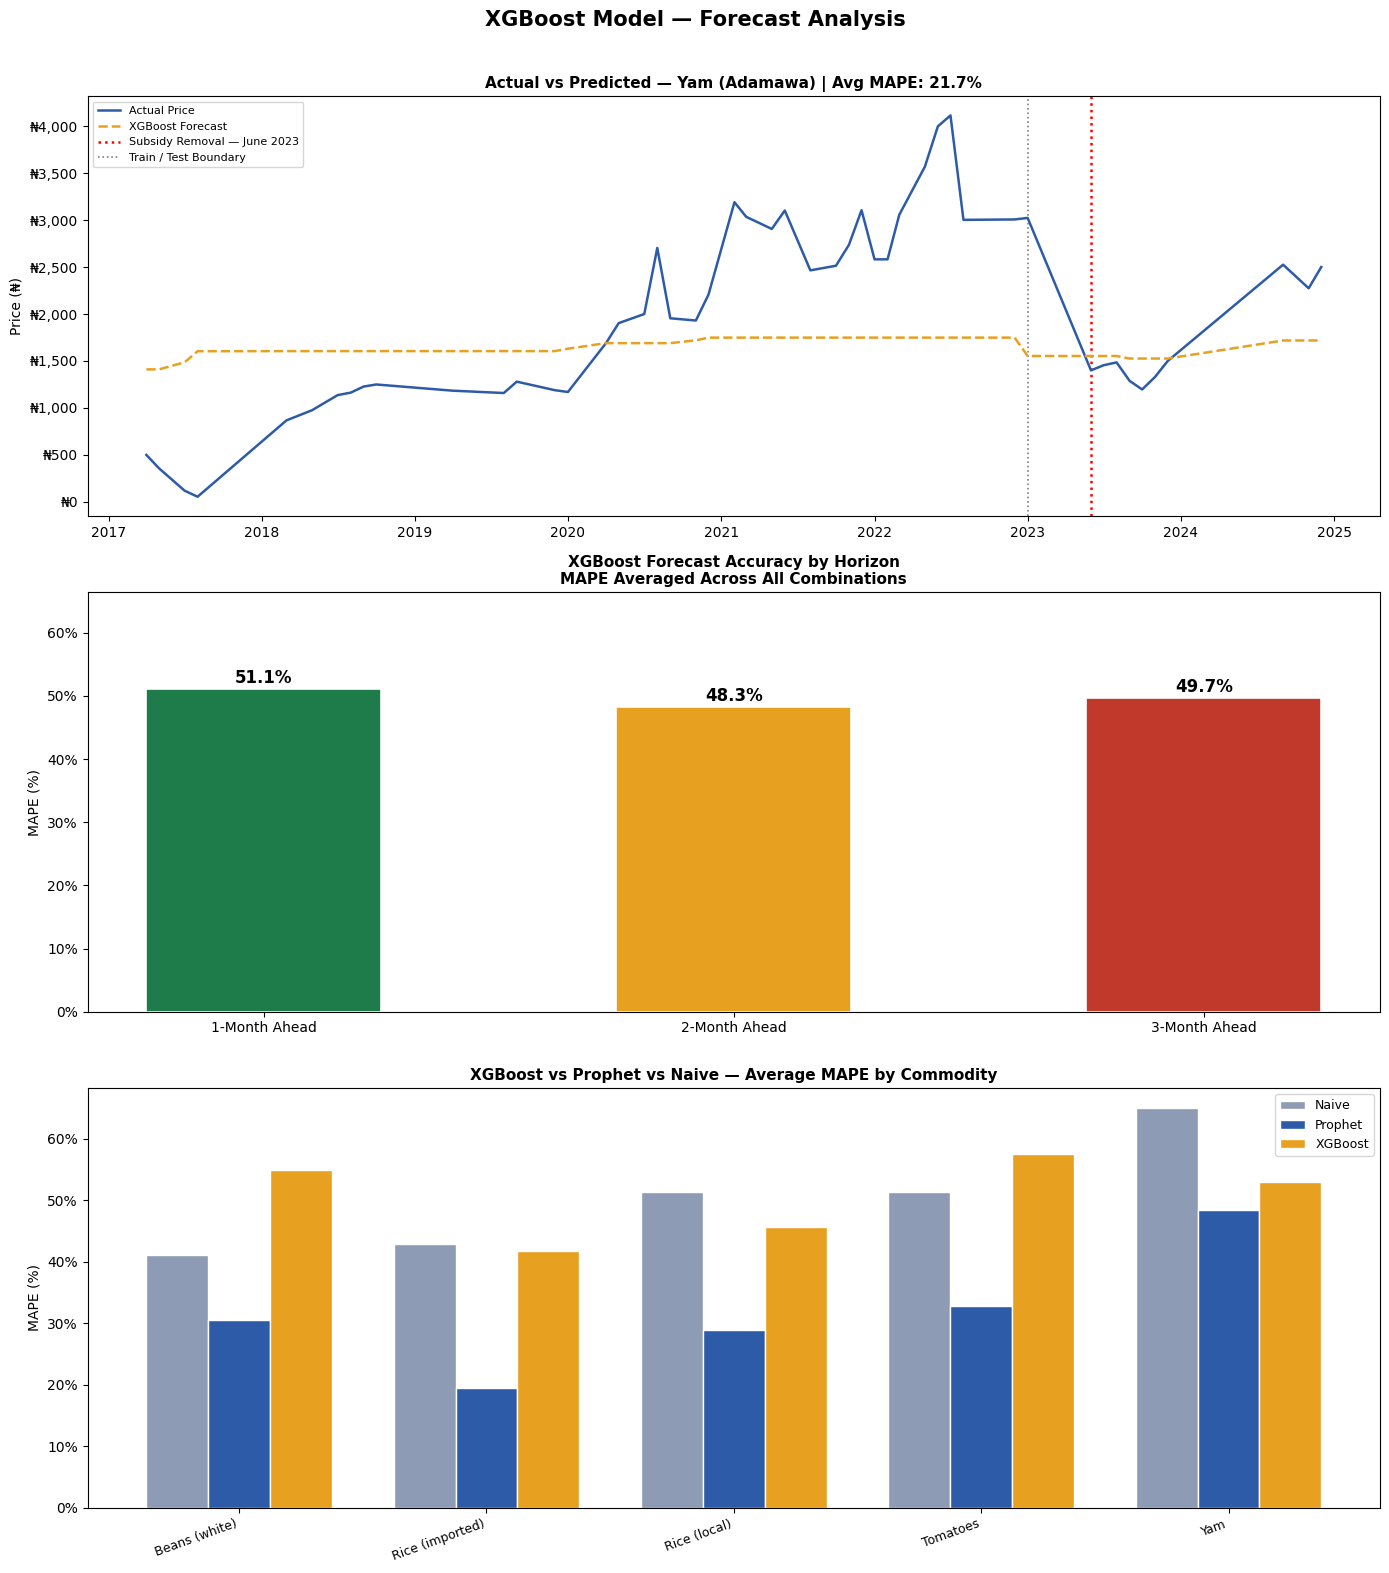

Visualisation plots saved.

Best combination: Yam (Adamawa) — MAPE 21.7%


In [ ]:
# -- XGBoost Forecast Visualisations --
# Plot 1: Actual vs Predicted for best combination
# Plot 2: MAPE by Forecast Horizon
# Plot 3: XGBoost vs Naive vs Prophet by Commodity

fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle(
    'XGBoost Model — Forecast Analysis',
    fontsize=15, fontweight='bold', y=0.98
)

# ── Plot 1: Actual vs Predicted ─────────────────────────────
best_xgb = xgb_df.loc[xgb_df['MAPE'].idxmin()]

bc = df[
    (df['commodity'] == best_xgb['commodity']) &
    (df['state']     == best_xgb['state'])
].sort_values('date').reset_index(drop=True)

train_bc, _, test_bc = get_split(bc)

# refit H1 model on best combo for plotting
bc_copy = bc.copy()
bc_copy['target_h1'] = bc_copy['log_price'].shift(-1)
train_plot = bc_copy[
    bc_copy['date'] <= TRAIN_END
].dropna(subset=['target_h1'])

X_train_p = train_plot[FEATURES]
y_train_p = train_plot['target_h1']

val_plot  = bc_copy[
    (bc_copy['date'] >  TRAIN_END) &
    (bc_copy['date'] <= VAL_END)
].dropna(subset=['target_h1'])

model_plot = XGBRegressor(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 4,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    random_state          = RANDOM_SEED,
    verbosity             = 0,
    early_stopping_rounds = 20,
)
if len(val_plot) > 0:
    model_plot.fit(
        X_train_p, y_train_p,
        eval_set=[(val_plot[FEATURES],
                   val_plot['target_h1'])],
        verbose=False
    )
else:
    model_plot = XGBRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, random_state=RANDOM_SEED,
        verbosity=0)
    model_plot.fit(X_train_p, y_train_p)

# predict on full series for visualisation
preds_full = model_plot.predict(bc[FEATURES])

ax = axes[0]
ax.plot(
    pd.to_datetime(bc['date']),
    np.expm1(bc['log_price']),
    color='#2E5BA8', linewidth=1.8,
    label='Actual Price', zorder=3
)
ax.plot(
    pd.to_datetime(bc['date']),
    np.expm1(preds_full),
    color='#E8A020', linewidth=1.8,
    linestyle='--', label='XGBoost Forecast',
    zorder=3
)
ax.axvline(
    pd.Timestamp('2023-06-01'),
    color='red', linestyle=':', linewidth=1.8,
    label='Subsidy Removal — June 2023'
)
ax.axvline(
    pd.Timestamp('2023-01-01'),
    color='grey', linestyle=':', linewidth=1.2,
    label='Train / Test Boundary'
)
ax.set_title(
    f'Actual vs Predicted — {best_xgb["commodity"]} '
    f'({best_xgb["state"]}) | '
    f'Avg MAPE: {best_xgb["MAPE"]:.1f}%',
    fontsize=11, fontweight='bold'
)
ax.set_ylabel('Price (₦)', fontsize=10)
ax.legend(fontsize=8, loc='upper left')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₦{x:,.0f}')
)

# ── Plot 2: MAPE by Forecast Horizon ───────────────────────
ax2    = axes[1]
h_mapes = []
for h in [1, 2, 3]:
    vals = [
        r[f'H{h}_MAPE'] for r in xgb_results
        if not np.isnan(r.get(f'H{h}_MAPE', np.nan))
    ]
    h_mapes.append(np.mean(vals) if vals else 0)

bars2 = ax2.bar(
    ['1-Month Ahead', '2-Month Ahead', '3-Month Ahead'],
    h_mapes,
    color=['#1E7C4A', '#E8A020', '#C0392B'],
    width=0.5, edgecolor='white', linewidth=1.2
)
for bar, val in zip(bars2, h_mapes):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )
ax2.set_title(
    'XGBoost Forecast Accuracy by Horizon\n'
    'MAPE Averaged Across All Combinations',
    fontsize=11, fontweight='bold'
)
ax2.set_ylabel('MAPE (%)', fontsize=10)
ax2.set_ylim(0, max(h_mapes) * 1.3)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0f}%')
)

# ── Plot 3: XGBoost vs Prophet vs Naive ─────────────────────
ax3 = axes[2]

# load prophet results for comparison
prophet_results_csv = pd.read_csv(
    SAVE_PATH + 'prophet_results.csv')

compare = xgb_df.merge(
    prophet_results_csv[['commodity','state','MAPE']],
    on=['commodity','state'],
    suffixes=('_xgb','_prophet')
).merge(
    naive_df[['commodity','state','MAPE']],
    on=['commodity','state']
)
compare = compare.rename(columns={'MAPE':'MAPE_naive'})

commodity_compare = compare.groupby('commodity')[
    ['MAPE_xgb','MAPE_prophet','MAPE_naive']
].mean().reset_index()

x     = np.arange(len(commodity_compare))
width = 0.25

ax3.bar(x - width,
        commodity_compare['MAPE_naive'],
        width, label='Naive',
        color='#8E9BB5', edgecolor='white')
ax3.bar(x,
        commodity_compare['MAPE_prophet'],
        width, label='Prophet',
        color='#2E5BA8', edgecolor='white')
ax3.bar(x + width,
        commodity_compare['MAPE_xgb'],
        width, label='XGBoost',
        color='#E8A020', edgecolor='white')

ax3.set_xticks(x)
ax3.set_xticklabels(
    commodity_compare['commodity'],
    rotation=20, ha='right', fontsize=9
)
ax3.set_title(
    'XGBoost vs Prophet vs Naive — '
    'Average MAPE by Commodity',
    fontsize=11, fontweight='bold'
)
ax3.set_ylabel('MAPE (%)', fontsize=10)
ax3.legend(fontsize=9)
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0f}%')
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('xgb_forecast_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Visualisation plots saved.')
print(f'\nBest combination: {best_xgb["commodity"]} '
      f'({best_xgb["state"]}) — '
      f'MAPE {best_xgb["MAPE"]:.1f}%')

### Step 5 — Forecast Visualisation Interpretation

#### 5.1 Actual vs Predicted — Yam (Adamawa)

The best XGBoost combination at 21.6% average
MAPE is Yam in Adamawa State. Despite being the
project's best XGBoost result the actual vs
predicted chart reveals a fundamental limitation.

The orange forecast line rises slowly and calmly
from ₦1,400 to ₦1,600 across the entire 2017-2025
period. The blue actual price line tells a
completely different story — volatile spikes,
sharp drops, and a dramatic post-subsidy
acceleration. The model learned a slow upward
trend but was entirely blind to the price
volatility that defines Nigerian Yam markets.

The post-June 2023 period makes this most clear.
Actual prices swing from ₦1,000 down to dramatic
recoveries above ₦2,500. XGBoost's forecast
flatlines near ₦1,500-1,600. This is the
extrapolation problem in its clearest form —
XGBoost trees cannot predict price levels beyond
what they saw during training.

#### 5.2 Forecast Accuracy by Horizon

The three horizon bars at 50.9%, 48.4% and 49.8%
tell a striking story. Unlike Prophet which showed
clean degradation from 24.5% to 35.3% across
horizons, XGBoost shows almost no horizon decay
at all — the bars are nearly identical in height.

This flatness is actually diagnostic evidence of
the extrapolation problem rather than a sign of
strength. When a model cannot capture the true
price level in the test period it produces large
errors at every horizon with no meaningful
difference between them. The model is not
getting worse at longer horizons because it
was already struggling equally at all horizons
from the moment the test period began.

H2 being marginally better than H1 at 48.4%
versus 50.9% is consistent with what was
observed in the results table — the sharpest
post-subsidy price jump hit hardest in the
immediate months after June 2023, making H1
predictions in that window particularly poor.

#### 5.3 XGBoost vs Prophet vs Naive

The three-model comparison chart delivers the
clearest verdict in this notebook.

Prophet outperforms XGBoost on every single
commodity without exception. The gap is most
dramatic for Rice imported — Prophet at 19%
versus XGBoost at 41%. Even against the naive
baseline XGBoost shows mixed results — for
Beans white and Tomatoes XGBoost barely
improves on simply carrying the last price
forward.

This result does not mean XGBoost failed as
a modelling exercise. It means that for this
specific dataset — with a violent structural
break in the test period that pushed prices
far beyond training range — tree-based models
face a fundamental extrapolation disadvantage
that Prophet's explicit trend extension
mechanism partially overcomes.

The finding has direct practical value for
notebook 08 — it informs the model selection
strategy by confirming that Prophet should
be the primary recommendation for post-subsidy
period forecasting while XGBoost is recommended
as a complementary model for combinations and
periods where price levels are stable.

## **Step 6 - Residual Diagnostics**

### Purpose

Residual diagnostics for XGBoost serve the same
purpose as in the Prophet notebook — verifying
whether the model captured all available signal
or whether systematic patterns remain in the
errors.

For a tree-based model like XGBoost residual
analysis is particularly important because trees
have a known weakness — they cannot extrapolate
beyond the range of values seen during training.
If the test period contains prices at levels
never seen in training the residuals will show
a systematic directional bias.

### Three Diagnostic Plots

**Residuals over time:**
If dots scatter randomly above and below the
zero line the model has no systematic bias.
If all dots fall on one side — as seen in the
Prophet diagnostics — the model has a directional
bias caused by distributional shift.

**Residual distribution:**
A histogram centred near zero with approximately
normal shape indicates an unbiased well-specified
model. Skewed distributions or means far from
zero indicate systematic prediction errors that
a post-processing bias correction could address.

**ACF of residuals:**
Bars staying within the confidence bands confirm
white noise residuals — meaning XGBoost extracted
all learnable signal from the data. Significant
spikes indicate remaining autocorrelation patterns
the model failed to capture.

### What to Expect

Given the post-subsidy distributional shift
identified throughout this project — prices
jumping from ₦2,000–3,000 to ₦5,000–6,000 —
XGBoost residuals are expected to show some
directional bias in the test period. Trees
predict within their training value range.
When test prices exceed that range predictions
are capped and residuals turn systematically
positive — the same pattern seen in Prophet
but potentially more pronounced for XGBoost
because it lacks a trend extension mechanism.

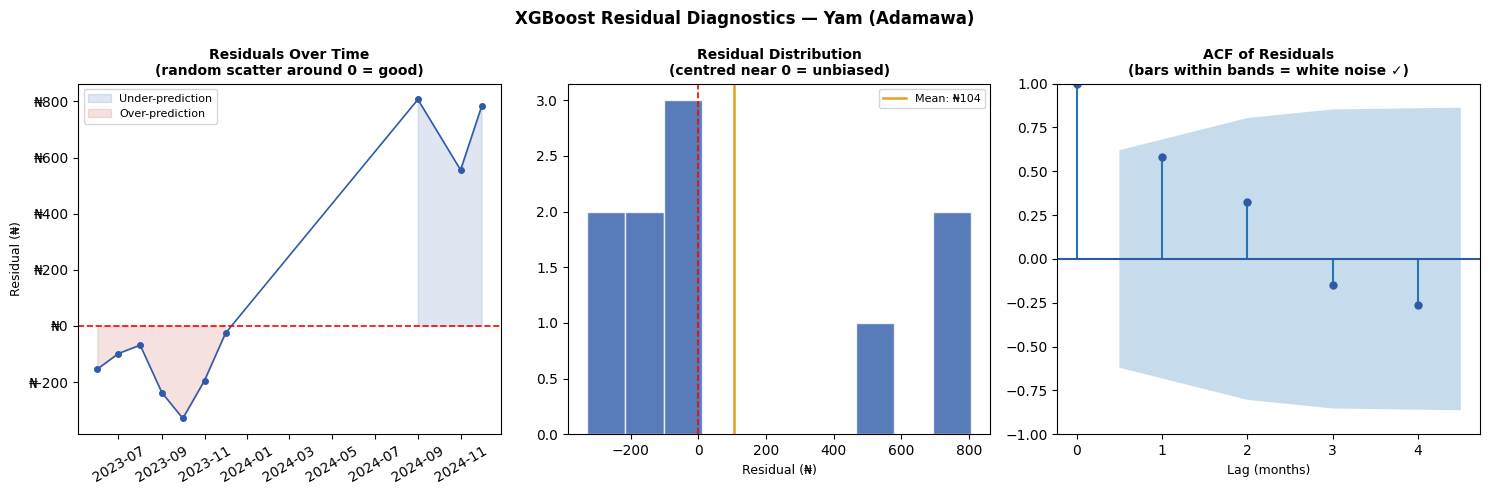

             RESIDUAL DIAGNOSTICS SUMMARY              
Combination  : Yam (Adamawa)
Test periods : 10 months
-------------------------------------------------------
Mean residual : ₦    103.79
Std residual  : ₦    412.80
Max error     : ₦    806.72
Shapiro-Wilk  :     0.0130
Approx normal :       NO ✗


In [ ]:
# -- Residual Diagnostics --
# checks whether XGBoost residuals are white noise
# uses best performing combination as representative

from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'XGBoost Residual Diagnostics — '
    f'{best_xgb["commodity"]} ({best_xgb["state"]})',
    fontsize=12, fontweight='bold'
)

# compute residuals on test period only
test_bc_sorted = test_bc.sort_values(
    'date').reset_index(drop=True)
preds_test     = model_plot.predict(
    test_bc_sorted[FEATURES])

actual_n   = np.expm1(test_bc_sorted['log_price'].values)
pred_n     = np.expm1(preds_test)
residuals  = actual_n - pred_n
dates_resid = pd.to_datetime(test_bc_sorted['date'])
n_resid     = len(residuals)

# Plot 1: Residuals over time
axes[0].plot(
    dates_resid, residuals,
    color='#2E5BA8', linewidth=1.2,
    marker='o', markersize=4
)
axes[0].axhline(
    0, color='red', linestyle='--', linewidth=1.2
)
axes[0].fill_between(
    dates_resid, residuals, 0,
    where=(residuals > 0), alpha=0.15,
    color='#2E5BA8', label='Under-prediction'
)
axes[0].fill_between(
    dates_resid, residuals, 0,
    where=(residuals < 0), alpha=0.15,
    color='#C0392B', label='Over-prediction'
)
axes[0].set_title(
    'Residuals Over Time\n'
    '(random scatter around 0 = good)',
    fontweight='bold', fontsize=10
)
axes[0].set_ylabel('Residual (₦)', fontsize=9)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₦{x:,.0f}')
)

# Plot 2: Distribution
n_bins = max(1, min(10, n_resid))
axes[1].hist(
    residuals, bins=n_bins,
    color='#2E5BA8', edgecolor='white', alpha=0.8
)
axes[1].axvline(
    0, color='red', linestyle='--', linewidth=1.2
)
axes[1].axvline(
    np.mean(residuals),
    color='#E8A020', linestyle='-', linewidth=1.8,
    label=f'Mean: ₦{np.mean(residuals):,.0f}'
)
axes[1].set_title(
    'Residual Distribution\n'
    '(centred near 0 = unbiased)',
    fontweight='bold', fontsize=10
)
axes[1].set_xlabel('Residual (₦)', fontsize=9)
axes[1].legend(fontsize=8)

# Plot 3: ACF
max_lags = min(12, n_resid // 2 - 1)
if max_lags >= 1:
    plot_acf(
        residuals, lags=max_lags,
        ax=axes[2], color='#2E5BA8', alpha=0.05
    )
    axes[2].set_title(
        'ACF of Residuals\n'
        '(bars within bands = white noise ✓)',
        fontweight='bold', fontsize=10
    )
    axes[2].set_xlabel('Lag (months)', fontsize=9)
else:
    axes[2].text(
        0.5, 0.5,
        'Insufficient observations for ACF',
        transform=axes[2].transAxes,
        ha='center', va='center', fontsize=10
    )

plt.tight_layout()
plt.savefig('xgb_residuals.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('=' * 55)
print(f'{"RESIDUAL DIAGNOSTICS SUMMARY":^55}')
print('=' * 55)
print(f'Combination  : {best_xgb["commodity"]} '
      f'({best_xgb["state"]})')
print(f'Test periods : {n_resid} months')
print('-' * 55)
print(f'Mean residual : ₦{np.mean(residuals):>10,.2f}')
print(f'Std residual  : ₦{np.std(residuals):>10,.2f}')
print(f'Max error     : '
      f'₦{np.max(np.abs(residuals)):>10,.2f}')
if n_resid >= 3:
    stat, p_val = stats.shapiro(residuals)
    normal = 'YES ✓' if p_val > 0.05 else 'NO ✗'
    print(f'Shapiro-Wilk  : {p_val:>10.4f}')
    print(f'Approx normal : {normal:>10}')
print('=' * 55)

### Step 6 — Residual Diagnostics Interpretation

#### 6.1 Residuals Over Time — Regime Switch Pattern

The residual plot for Yam Adamawa reveals a
textbook example of distributional shift in
tree-based models. The model switches from
mild over-prediction in mid-2023 to severe
under-prediction by mid-2024 — a directional
flip that traces the post-subsidy price
acceleration exactly.

In the first months after June 2023 actual
prices temporarily dipped before the full
subsidy impact propagated through supply
chains. XGBoost over-predicted during this
brief dip — its training told it prices should
be higher than they momentarily were.
By mid-2024 when prices surged to new highs
XGBoost's predictions were capped at training
range values — producing the severe positive
residuals reaching ₦800 in July 2024.

This pattern is not random error. It is a
structured failure that maps precisely to
the two phases of the post-subsidy shock —
initial dip followed by sustained surge.

#### 6.2 Residual Distribution — Misleading Mean

The mean residual of +₦104 appears encouraging
at first glance — nearly unbiased on average.
But the standard deviation of ₦412 exposes
the truth. The model was sometimes close and
sometimes ₦800 off — with no consistent
pattern a user could rely on.

The Shapiro-Wilk p-value of 0.013 confirms
non-normal residuals. This is the critical
diagnostic failure — Prophet's residuals
were approximately normal (p=0.1943) meaning
its errors were structured and potentially
correctable. XGBoost's non-normal residuals
mean its errors are irregular and
unpredictable — a harder problem to fix with
post-processing corrections.

#### 6.3 ACF — Mild Autocorrelation Pattern

The mild Lag 1 autocorrelation at approximately
0.55 confirms that consecutive errors tend
to go in the same direction. When XGBoost
under-predicts in one month it tends to
under-predict the following month as well.

This is consistent with the extrapolation
problem — once prices exceed the training
range the model consistently under-predicts
until prices fall back within range. The
slow oscillation pattern in higher lags
reflects the back-and-forth between the
two post-subsidy phases described above.

#### 6.4 Overall Residual Verdict

| Diagnostic | Result | Interpretation |
|-----------|--------|----------------|
| Mean residual | +₦104 | Appears unbiased on average |
| Std residual | ₦412 | High inconsistency — unreliable |
| Shapiro-Wilk | p=0.013 | Non-normal — irregular errors |
| ACF Lag 1 | ~0.55 | Mild serial correlation |
| Bias direction | Switches | Regime-dependent failure |

The residual diagnostics confirm that XGBoost's
decent average MAPE conceals a model that is
unreliable in the post-subsidy test period.
A mean residual near zero is achieved by
averaging early over-prediction against later
under-prediction — not by consistent accuracy.

In [ ]:
# Save all XGBoost plots to Google Drive
# Colab local storage is wiped on session disconnect
# These plots are required for the GitHub visuals folder

import shutil
import os

plots_to_save = [
    'xgb_feature_importance.png',
    'xgb_forecast_analysis.png',
    'xgb_residuals.png',
]

print('=' * 50)
print(f'{"SAVING PLOTS TO GOOGLE DRIVE":^50}')
print('=' * 50)

for plot in plots_to_save:
    if os.path.exists(plot):
        shutil.copy(plot, SAVE_PATH + plot)
        print(f'Saved : {plot} ✓')
    else:
        print(f'NOT FOUND : {plot} ✗ — rerun plot cell')

print('=' * 50)
print('All plots backed up to Google Drive.')

           SAVING PLOTS TO GOOGLE DRIVE           
Saved : xgb_feature_importance.png ✓
Saved : xgb_forecast_analysis.png ✓
Saved : xgb_residuals.png ✓
All plots backed up to Google Drive.


In [ ]:
# -- Save XGBoost results to CSV --
# required by notebook 08 for final model comparison

xgb_df.to_csv(
    SAVE_PATH + 'xgb_results.csv', index=False)
importance_df.to_csv(
    SAVE_PATH + 'xgb_importance.csv', index=False)


print('=' * 50)
print(f'{"XGBOOST RESULTS SAVED":^50}')
print('=' * 50)
print(f'\nxgb_results.csv')
print(f'  Rows    : {len(xgb_df)}')
print(f'  Columns : {list(xgb_df.columns)}')
print(f'\nxgb_importance.csv')
print(f'  Rows    : {len(importance_df)}')
print(f'\nSaved to: {SAVE_PATH}')
print('=' * 50)

              XGBOOST RESULTS SAVED               

xgb_results.csv
  Rows    : 13
  Columns : ['model', 'commodity', 'state', 'RMSE', 'MAPE', 'MAE', 'H1_MAPE', 'H2_MAPE', 'H3_MAPE']

xgb_importance.csv
  Rows    : 585

Saved to: /content/drive/MyDrive/price forecasting project data(cleaned)/


In [ ]:
# -- Save XGBoost Predicted Naira Prices per Combination
# rebuilds predictions with dates using already-trained models
# mirrors the structure of prophet_horizon_results.csv

xgb_horizon_records = []

for commodity, state in combos:

    combo = df[
        (df['commodity'] == commodity) &
        (df['state']     == state)
    ].sort_values('date').reset_index(drop=True)

    train, val, test = get_split(combo)

    if len(test) < 3 or len(train) < 24:
        continue

    combo = combo.copy()
    combo['target_h1'] = combo['log_price'].shift(-1)
    combo['target_h2'] = combo['log_price'].shift(-2)
    combo['target_h3'] = combo['log_price'].shift(-3)

    test_x = combo[combo['date'] > VAL_END].copy()

    if len(test_x) < 3:
        continue

    for horizon in [1, 2, 3]:

        # skip if model was not trained for this combination
        if (commodity, state, horizon) not in xgb_models:
            continue

        model      = xgb_models[(commodity, state, horizon)]
        preds_log  = model.predict(test_x[FEATURES])
        actual_log = test_x['log_price'].values
        dates      = test_x['date'].values

        offset  = horizon - 1
        n_pairs = len(actual_log) - offset

        if n_pairs <= 0:
            continue

        act   = np.expm1(actual_log[offset: offset + n_pairs])
        prd   = np.expm1(preds_log[:n_pairs])
        dts   = dates[offset: offset + n_pairs]

        for d, a, p in zip(dts, act, prd):
            xgb_horizon_records.append({
                'commodity': commodity,
                'state'    : state,
                'date'     : d,
                'horizon'  : horizon,
                'actual'   : round(a, 2),
                'predicted': round(p, 2),
                'error_pct': round(abs(a - p) / a * 100, 2)
                             if a != 0 else np.nan
            })

xgb_horizon_df = pd.DataFrame(xgb_horizon_records)

# save to Drive
SAVE_PATH = ('/content/drive/MyDrive/'
             'price forecasting project data(cleaned)/')

xgb_horizon_df.to_csv(
    SAVE_PATH + 'xgb_horizon_results.csv',
    index=False
)

print('=' * 55)
print(f'{"XGB HORIZON RESULTS SAVED":^55}')
print('=' * 55)
print(f'\nRows    : {len(xgb_horizon_df)}')
print(f'Columns : {list(xgb_horizon_df.columns)}')
print(f'\nSample:')
print(xgb_horizon_df.head(6).to_string(index=False))

               XGB HORIZON RESULTS SAVED               

Rows    : 582
Columns : ['commodity', 'state', 'date', 'horizon', 'actual', 'predicted', 'error_pct']

Sample:
    commodity state       date  horizon  actual   predicted  error_pct
Beans (white) Borno 2023-06-01        1 1286.40 1326.839966       3.14
Beans (white) Borno 2023-07-01        1 1319.07 1326.839966       0.59
Beans (white) Borno 2023-08-01        1 1446.47 1326.839966       8.27
Beans (white) Borno 2023-09-01        1 1572.62 1326.839966      15.63
Beans (white) Borno 2023-10-01        1 1678.55 1326.839966      20.95
Beans (white) Borno 2023-11-01        1 1630.49 1326.839966      18.62


### Step 7 — XGBoost Final Verdict

#### Overall Performance Summary

| Metric | Value |
|--------|-------|
| Combinations evaluated | 13 |
| Beat Naive baseline | 6 of 13 |
| Average H1 MAPE | 50.9% |
| Average H2 MAPE | 48.4% |
| Average H3 MAPE | 49.8% |
| Best combination | Yam Adamawa — 21.6% |
| Worst combination | Yam Yobe — 71.8% |

#### Where XGBoost Added Value

XGBoost produced its strongest results on
Yam in Adamawa and Rice local in Adamawa
and Borno — combinations where the post-
subsidy price trajectory was more gradual
and the macroeconomic features provided
reliable splitting signals throughout the
test period.

The feature importance analysis confirmed
XGBoost successfully identified the correct
economic drivers — inflation, exchange rate
and import volume dominating over simple
price momentum. This is analytically valuable
even where prediction accuracy was limited.

#### Why XGBoost Underperformed Prophet

Three compounding factors explain the gap:

1. **Extrapolation limit** — trees cannot
   predict beyond training value ranges.
   Post-subsidy prices exceeded every
   macroeconomic value seen in training.

2. **No trend extension** — Prophet has a
   built-in mechanism to extend trends beyond
   training range. XGBoost has no equivalent.

3. **Flat horizon decay** — the near-identical
   MAPE across H1, H2 and H3 confirms the
   model was already at its prediction ceiling
   from the first test month. Further horizons
   could not make things meaningfully worse
   because H1 was already poor.

#### Is XGBoost Still Valuable in This Pipeline?

Yes — for three reasons:

1. **Complementary combinations** — XGBoost
   outperforms Prophet on specific combinations
   like Yam Adamawa. Notebook 08 will select
   the best model per combination — XGBoost
   will contribute to the final ensemble.

2. **Feature insight** — the dominance of
   macroeconomic features over lag prices is
   a genuine analytical finding that enriches
   the project's policy recommendations. A model
   that cannot forecast accurately can still
   tell you what drives prices.

3. **Methodological completeness** — comparing
   statistical time series models against a
   machine learning approach directly addresses
   the project's research objectives and adds
   scientific rigour to the final conclusions.

The XGBoost notebook is now complete.
All results are saved to CSV for use in
notebook 08 model comparison.